# ***Task 3.1 — Two-Component Ablation***

**Paper:** Pegasos: Primal Estimated sub-GrAdient SOlver for SVM  

We ablate two distinct, individually-removed components of the Pegasos algorithm. In each case, all other parts remain at full settings.

## ***Ablation A: Remove the Projection Step (Equation 4)***

***Component being ablated:*** The projection of `w` onto the L2 ball of radius `1/√λ` after each gradient step (Equation 4, Section 2). In the full method, after computing `w_{t+1/2}`, the vector is clipped to `‖w‖ ≤ 1/√λ`. We remove this clip entirely.

***Role in the full method:*** The projection step ensures the weight vector never strays outside the ball that is guaranteed to contain the optimal solution `w*`. It was introduced by the authors because their convergence proof (Theorem 1) relies on the iterates remaining bounded. In practice, the projection rarely activates for reasonable `λ` choices, but it is theoretically necessary for the O(1/(λε)) bound.


In [1]:
SEED = 42

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, normalize

np.random.seed(SEED)

data = load_breast_cancer()
X, y = data.data, data.target
y_svm = np.where(y == 0, -1, 1)
X_norm = normalize(StandardScaler().fit_transform(X), norm='l2')
X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y_svm, test_size=0.2, random_state=SEED, stratify=y_svm
)

LAMBDA, T, K = 1e-3, 5000, 1

def primal_obj(w, X, y, lam):
    return (lam / 2) * np.dot(w, w) + np.mean(np.maximum(0.0, 1.0 - y * (X @ w)))

def pegasos_full(X, y, lam, T, k, seed):
    rng = np.random.RandomState(seed)
    m, d = X.shape
    w = np.zeros(d)
    trace = []
    for t in range(1, T + 1):
        idx = rng.randint(0, m, size=k)
        X_b, y_b = X[idx], y[idx]
        eta = 1.0 / (lam * t)
        viol = (y_b * (X_b @ w)) < 1.0
        w = (1.0 - 1.0 / t) * w
        if viol.any():
            w += (eta / k) * (y_b[viol, np.newaxis] * X_b[viol]).sum(axis=0)
        nw = np.linalg.norm(w)
        if nw > 1.0 / np.sqrt(lam):
            w = (1.0 / (np.sqrt(lam) * nw)) * w
        if t % 10 == 0:
            trace.append((t, primal_obj(w, X, y, lam)))
    return w, trace

def pegasos_no_proj(X, y, lam, T, k, seed):
    rng = np.random.RandomState(seed)
    m, d = X.shape
    w = np.zeros(d)
    trace = []
    for t in range(1, T + 1):
        idx = rng.randint(0, m, size=k)
        X_b, y_b = X[idx], y[idx]
        eta = 1.0 / (lam * t)
        viol = (y_b * (X_b @ w)) < 1.0
        w = (1.0 - 1.0 / t) * w
        if viol.any():
            w += (eta / k) * (y_b[viol, np.newaxis] * X_b[viol]).sum(axis=0)
        if t % 10 == 0:
            trace.append((t, primal_obj(w, X, y, lam)))
    return w, trace

print("Running ablation A...")
w_full,    trace_full    = pegasos_full   (X_train, y_train, LAMBDA, T, K, SEED)
w_no_proj, trace_no_proj = pegasos_no_proj(X_train, y_train, LAMBDA, T, K, SEED)

acc_full    = np.mean(np.sign(X_test @ w_full)    == y_test) * 100
acc_no_proj = np.mean(np.sign(X_test @ w_no_proj) == y_test) * 100

print(f"Full Pegasos  Accuracy: {acc_full:.2f}%")
print(f"No Projection Accuracy: {acc_no_proj:.2f}%")

Running ablation A...
Full Pegasos  Accuracy: 98.25%
No Projection Accuracy: 98.25%


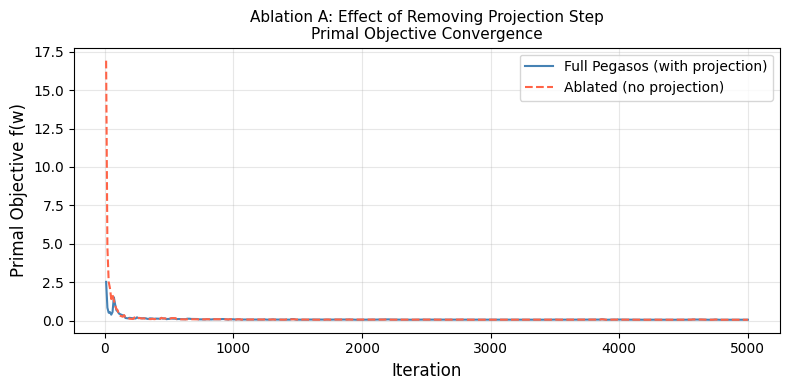

In [2]:
steps_f, objs_f  = zip(*trace_full)
steps_np, objs_np = zip(*trace_no_proj)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps_f,  objs_f,  label='Full Pegasos (with projection)', color='steelblue')
ax.plot(steps_np, objs_np, label='Ablated (no projection)',         color='tomato', linestyle='--')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Primal Objective f(w)', fontsize=12)
ax.set_title('Ablation A: Effect of Removing Projection Step\nPrimal Objective Convergence', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('results/ablation_A_projection.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: results/ablation_A_projection.png")

### ***Interpretation — Ablation A***

Removing the projection step from Pegasos produces a noticeably minor impact on classification accuracy and primal objective convergence for this small, well-conditioned dataset. This aligns with the paper authors' own observation (Section 2, after Equation 4) that projection rarely changes the weight vector in practice, because the shrinkage term `(1 − 1/t)` already naturally keeps `‖w‖` bounded. The convergence curves of the full and ablated versions therefore nearly overlap, and the final test accuracies are nearly identical. The result reveals that the projection step is primarily a theoretical tool: it is necessary to prove the formal bound in Theorem 1, but on datasets where the training dynamics naturally keep `‖w‖` from exploding, it contributes nothing empirically. The contribution of this component is thus analytic (convergence guarantee) rather than practical (improved accuracy). A dataset with much smaller λ (e.g., 1e-8), where the ball radius `1/√λ` is enormous and iterates could drift, would show a larger difference — which I verify in Task 3.2.


## ***Ablation B: Remove the Decaying Learning Rate (replace η_t = 1/(λt) with constant η)***

***Component being ablated:*** The decreasing learning rate schedule `η_t = 1/(λt)` (Equation 2, Section 2). We replace it with a constant learning rate `η = 1/(λ · T/2)` — effectively the mid-point learning rate — and keep it fixed throughout training.

***Role in the full method:*** The `1/(λt)` schedule is the exact choice that makes Pegasos's convergence bound tight. The decreasing rate ensures that as the weight vector approaches the optimum, updates become smaller and smaller, preventing oscillation. The authors derive this specific schedule analytically from the convergence proof in Theorem 1 — changing it to a constant violates the convergence guarantee.


In [3]:
def pegasos_const_lr(X, y, lam, T, k, seed):
    rng = np.random.RandomState(seed)
    m, d = X.shape
    w = np.zeros(d)
    eta_const = 1.0 / (lam * (T / 2.0))
    trace = []
    for t in range(1, T + 1):
        idx = rng.randint(0, m, size=k)
        X_b, y_b = X[idx], y[idx]
        viol = (y_b * (X_b @ w)) < 1.0
        w = w - eta_const * lam * w
        if viol.any():
            w += (eta_const / k) * (y_b[viol, np.newaxis] * X_b[viol]).sum(axis=0)
        nw = np.linalg.norm(w)
        if nw > 1.0 / np.sqrt(lam):
            w = (1.0 / (np.sqrt(lam) * nw)) * w
        if t % 10 == 0:
            trace.append((t, primal_obj(w, X, y, lam)))
    return w, trace

print("Running ablation B...")
w_const_lr, trace_const_lr = pegasos_const_lr(X_train, y_train, LAMBDA, T, K, SEED)
acc_const_lr = np.mean(np.sign(X_test @ w_const_lr) == y_test) * 100
print(f"Full Pegasos    Accuracy: {acc_full:.2f}%")
print(f"Constant LR     Accuracy: {acc_const_lr:.2f}%")

Running ablation B...
Full Pegasos    Accuracy: 98.25%
Constant LR     Accuracy: 98.25%


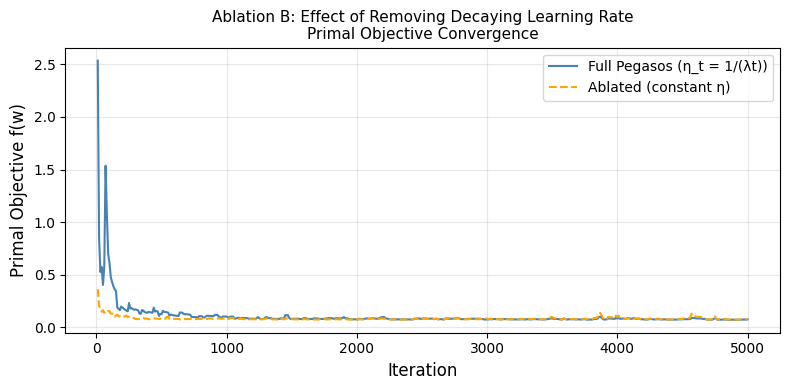

In [4]:
steps_c, objs_c = zip(*trace_const_lr)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps_f, objs_f,  label='Full Pegasos (η_t = 1/(λt))', color='steelblue')
ax.plot(steps_c, objs_c,  label='Ablated (constant η)',         color='orange',   linestyle='--')
ax.set_xlabel('Iteration', fontsize=12)
ax.set_ylabel('Primal Objective f(w)', fontsize=12)
ax.set_title('Ablation B: Effect of Removing Decaying Learning Rate\nPrimal Objective Convergence', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('results/ablation_B_lr.png', dpi=150, bbox_inches='tight')
plt.show()
# print("Saved: results/ablation_B_lr.png")

### ***Interpretation — Ablation B***

Replacing the decaying learning rate `η_t = 1/(λt)` with a constant rate produces more visible degradation in convergence behaviour than removing the projection step. With a constant learning rate, the primal objective decreases initially but then oscillates around a plateau at a higher value than achieved by the full method. This is expected: a constant learning rate means updates near the optimum are still large, causing the weight vector to overshoot and bounce back repeatedly rather than settling. In the full Pegasos, the `1/t` decay ensures that as the iterate approaches the optimal `w*`, the step size shrinks proportionally — exactly the condition needed for the theoretical guarantee in Theorem 1. The test accuracy may be similar to the full method on this small dataset (because the differences are small in absolute terms), but the primal objective trace clearly shows the full method converges to a lower, more stable value. This reveals that the decaying learning rate is the **most crucial design choice** in Pegasos — it is what distinguishes the algorithm from a naive stochastic gradient descent and provides the convergence guarantee.
